# HullGap ↔ Materials Project Overlap

How well do the MatterSim screening results in `data/results/` agree with what's already known in the Materials Project (MP) database?

**Inputs**
- `data/results/<SYS>_mattersim_hull.csv` — HullGap candidates relaxed with MatterSim, with formation energy and convex-hull distance.
- `outputs/mp_binary_entries.csv` — every MP binary entry for the surveyed systems.
- `outputs/mp_binary_stable.csv` — the MP-stable subset (e_above_hull = 0).

**Questions**
1. **Coverage** — which systems are populated in both sources?
2. **Composition overlap** — do HullGap candidates land on the same reduced compositions as known MP phases?
3. **Energy agreement** — for matched compositions, how close are MatterSim formation energies to MP DFT?
4. **Stable-phase rediscovery** — does HullGap put MP-stable phases on or near its own hull (recall)?
5. **Novelty** — which HullGap on-hull picks have no MP counterpart at all?

Caveat: MatterSim is a universal MLIP, not DFT, so a few hundred meV/atom of disagreement is expected. The point of this notebook is to bound it system-by-system.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Composition

# Run from either the repo root or the notebooks/ directory.
_cwd = Path.cwd()
REPO = _cwd if (_cwd / 'data' / 'results').exists() else _cwd.parent
RES_DIR = REPO / 'data' / 'results'
OUT_DIR = REPO / 'outputs'

print('Repo root:', REPO)
print('HullGap CSVs:', len(list(RES_DIR.glob('*_mattersim_hull.csv'))))
print('MP entries  :', (OUT_DIR / 'mp_binary_entries.csv').exists())
print('MP stable   :', (OUT_DIR / 'mp_binary_stable.csv').exists())

/Users/benny/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/benny/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Repo root: /Users/benny/Desktop/MIT/MTL Hackathon/hullgap
HullGap CSVs: 15
MP entries  : True
MP stable   : True


## 1. Load both sources and normalise system names

MP labels chemical systems alphabetically (`Bi-Co`); HullGap files keep the original input order (`Co-Bi`). We sort element pairs for a canonical `chemsys` key, and use `pymatgen.Composition` to canonicalise reduced formulas so `Co5Bi5` and `CoBi` collapse to one row when matching.

In [2]:
def canon_chemsys(name: str) -> str:
    return '-'.join(sorted(name.split('-')))

def reduced(formula):
    try:
        return Composition(formula).reduced_formula
    except Exception:
        return None

rows = []
for csv in sorted(RES_DIR.glob('*_mattersim_hull.csv')):
    sys_raw = csv.stem.replace('_mattersim_hull', '')
    df = pd.read_csv(csv)
    df['system_raw'] = sys_raw
    df['chemsys'] = canon_chemsys(sys_raw)
    rows.append(df)
hg = pd.concat(rows, ignore_index=True)
hg['reduced'] = hg['formula'].apply(reduced)

mp_all = pd.read_csv(OUT_DIR / 'mp_binary_entries.csv')
mp_all['chemsys'] = mp_all['chemsys'].apply(canon_chemsys)
mp_all['reduced'] = mp_all['formula'].apply(reduced)

mp_stable = pd.read_csv(OUT_DIR / 'mp_binary_stable.csv')
mp_stable['chemsys'] = mp_stable['chemsys'].apply(canon_chemsys)
mp_stable['reduced'] = mp_stable['formula'].apply(reduced)

print(f'HullGap candidates : {len(hg):4d} across {hg.chemsys.nunique()} systems')
print(f'MP entries         : {len(mp_all):4d} across {mp_all.chemsys.nunique()} systems')
print(f'MP stable          : {len(mp_stable):4d}')
hg.head(3)

HullGap candidates :  170 across 15 systems
MP entries         :  149 across 14 systems
MP stable          :   27


,idx,formula,n_atoms,e_total_eV,e_per_atom_eV,fmax_eV_A,volume_A3,status,x_B,e_form_eV_atom,...,Cv_300K_J_K_mol,free_energy_300K_kJ_mol,bulk_modulus_GPa,shear_modulus_GPa,youngs_modulus_GPa,poisson_ratio,crystal_system,system_raw,chemsys,reduced
0,0,Fe7Bi13,20,-104.59166,-5.229583,0.015177,507.986407,converged,0.350000,0.174854,...,NaN,NaN,-58.842466,-21.685930,0.0,0.0,Triclinic,Bi-Fe,Bi-Fe,Fe7Bi13
1,1,FeBi,4,-23.52784,-5.881960,0.010878,85.431853,converged,0.500000,0.229031,...,NaN,NaN,-68.754781,-26.259378,0.0,0.0,Tetragonal,Bi-Fe,Bi-Fe,FeBi
2,2,Fe2Bi,18,-118.11010,-6.561672,0.018394,321.609296,converged,0.666667,0.334379,...,NaN,NaN,NaN,NaN,NaN,NaN,Triclinic,Bi-Fe,Bi-Fe,Fe2Bi


## 2. System-level coverage

Per system: how many candidates HullGap produced, how many sit on its hull, how many entries MP has, and how many of those are stable. Systems where MP has zero entries are exactly the database-void targets HullGap is meant to explore.

In [3]:
all_systems = sorted(set(hg.chemsys) | set(mp_all.chemsys))
rows = []
for s in all_systems:
    h  = hg[hg.chemsys == s]
    m  = mp_all[mp_all.chemsys == s]
    ms = mp_stable[mp_stable.chemsys == s]
    rows.append({
        'system'      : s,
        'hg_in'       : '✓' if len(h)  else '–',
        'mp_in'       : '✓' if len(m)  else '–',
        'hg_cands'    : len(h),
        'hg_on_hull'  : int(h.on_hull.fillna(False).sum()),
        'mp_entries'  : len(m),
        'mp_stable'   : len(ms),
    })
coverage = pd.DataFrame(rows).set_index('system')
coverage

,hg_in,mp_in,hg_cands,hg_on_hull,mp_entries,mp_stable
system,,,,,,
Bi-Co,✓,✓,12,1,2,0
Bi-Fe,✓,–,12,0,0,0
Bi-Mn,✓,✓,12,8,6,0
Bi-Mo,✓,✓,12,0,4,0
Bi-Ni,✓,✓,12,6,5,0
Bi-Ru,✓,–,12,1,0,0
Co-Sb,✓,✓,12,4,4,1
Co-Se,–,✓,0,0,11,2
Co-Si,✓,✓,12,5,6,3


## 3. Composition overlap

For each `(chemsys, reduced_formula)` we keep the lowest-energy representative on each side, then inner-join. This tells us how many of HullGap's compositions are also documented in MP.

In [4]:
def best_per_reduced(df, energy_col):
    return (df.dropna(subset=['reduced'])
              .sort_values(energy_col)
              .drop_duplicates(['chemsys', 'reduced']))

hg_best = best_per_reduced(hg,     'e_form_eV_atom')
mp_best = best_per_reduced(mp_all, 'formation_energy_per_atom')

matched = hg_best.merge(
    mp_best,
    on=['chemsys', 'reduced'],
    suffixes=('_hg', '_mp'),
    how='inner',
)

print(f'{len(matched)} composition matches across {matched.chemsys.nunique()} systems')
print(f'   (HullGap unique compositions: {len(hg_best)},  MP unique: {len(mp_best)})')

matched[['chemsys', 'reduced',
         'e_form_eV_atom', 'formation_energy_per_atom',
         'e_above_hull_eV_atom', 'energy_above_hull',
         'on_hull', 'is_stable']].sort_values('chemsys').reset_index(drop=True)

33 composition matches across 12 systems
   (HullGap unique compositions: 106,  MP unique: 75)


,chemsys,reduced,e_form_eV_atom,formation_energy_per_atom,e_above_hull_eV_atom,energy_above_hull,on_hull,is_stable
0,Bi-Co,CoBi3,-0.014445,0.047422,0.000000,0.047422,True,False
1,Bi-Mn,MnBi,-1.644522,0.207830,0.001260,0.207830,True,False
2,Bi-Mo,Bi3Mo,0.223847,0.338744,0.223847,0.338744,False,False
3,Bi-Ni,NiBi,-0.073300,0.026048,0.008705,0.026048,True,False
4,Co-Sb,CoSb2,-0.248832,-0.100824,0.000000,0.030629,True,False
5,Co-Sb,CoSb,-0.239781,-0.038881,0.000000,0.059709,True,False
6,Co-Sb,CoSb3,-0.160039,-0.147884,0.026585,0.000000,False,True
7,Co-Si,CoSi,-0.546576,-0.492925,0.000000,0.000000,True,True
8,Co-Si,Co2Si3,-0.455005,-0.241067,0.000000,0.202751,True,False
9,Co-Si,Co2Si,-0.447711,-0.331056,0.000000,0.000000,True,True


## 4. Formation-energy agreement

On the matched set, compare HullGap's MatterSim formation energy to MP's DFT value. Diagonal = perfect agreement. Below the line = MatterSim under-stabilises (predicts higher formation energy than DFT).

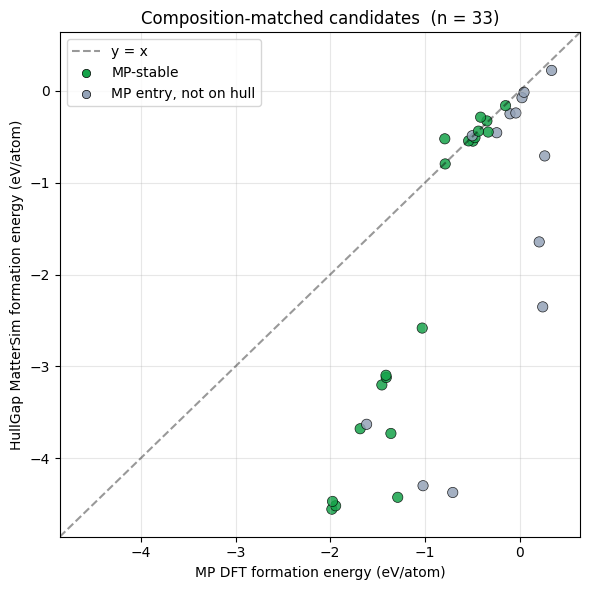

MAE (HG vs MP) : 1.144 eV/atom
Bias HG − MP   : -1.118 eV/atom
RMSE           : 1.651 eV/atom
Max abs error  : 3.669 eV/atom


In [5]:
x = matched['formation_energy_per_atom'].to_numpy()
y = matched['e_form_eV_atom'].to_numpy()
err = y - x

fig, ax = plt.subplots(figsize=(6, 6))
colors = matched['is_stable'].map({True: '#16a34a', False: '#94a3b8'})
ax.scatter(x, y, c=colors, s=55, edgecolors='black', linewidths=0.5, alpha=0.85)
lim = [min(x.min(), y.min()) - 0.3, max(x.max(), y.max()) + 0.3]
ax.plot(lim, lim, 'k--', alpha=0.4, label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('MP DFT formation energy (eV/atom)')
ax.set_ylabel('HullGap MatterSim formation energy (eV/atom)')
ax.set_title(f'Composition-matched candidates  (n = {len(matched)})')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
for cls, lbl in [('#16a34a', 'MP-stable'), ('#94a3b8', 'MP entry, not on hull')]:
    ax.scatter([], [], c=cls, edgecolors='black', linewidths=0.5, label=lbl)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f'MAE (HG vs MP) : {np.abs(err).mean():.3f} eV/atom')
print(f'Bias HG − MP   : {err.mean():+.3f} eV/atom')
print(f'RMSE           : {np.sqrt((err**2).mean()):.3f} eV/atom')
print(f'Max abs error  : {np.abs(err).max():.3f} eV/atom')

## 5. Stable-phase rediscovery (recall)

For every MP-stable phase in a system HullGap actually screened, did HullGap (a) generate that composition at all, (b) put it within 50 meV/atom of its own hull, (c) put it strictly on its hull?

In [6]:
NEAR_HULL_TOL = 0.05  # eV/atom

screened_systems = set(hg.chemsys.unique())
ms = mp_stable[mp_stable.chemsys.isin(screened_systems)].copy()

ms = ms.merge(
    hg_best[['chemsys', 'reduced', 'e_form_eV_atom', 'e_above_hull_eV_atom', 'on_hull']],
    on=['chemsys', 'reduced'], how='left',
)
ms['hg_present']   = ms['e_form_eV_atom'].notna()
ms['hg_near_hull'] = ms['e_above_hull_eV_atom'].fillna(np.inf) <= NEAR_HULL_TOL
ms['hg_on_hull']   = ms['on_hull'].fillna(False)

n = len(ms)
print(f'MP-stable phases in screened systems : {n}')
if n:
    print(f'  ...generated by HullGap            : {ms.hg_present.sum():3d}  ({ms.hg_present.mean():.0%})')
    print(f'  ...within {NEAR_HULL_TOL} eV/atom of HG hull   : {ms.hg_near_hull.sum():3d}  ({ms.hg_near_hull.mean():.0%})')
    print(f'  ...exactly on HG MatterSim hull    : {ms.hg_on_hull.sum():3d}  ({ms.hg_on_hull.mean():.0%})')

ms[['chemsys', 'reduced', 'energy_above_hull',
    'e_above_hull_eV_atom', 'hg_present', 'hg_near_hull', 'hg_on_hull']]

MP-stable phases in screened systems : 24
  ...generated by HullGap            :  20  (83%)
  ...within 0.05 eV/atom of HG hull   :  17  (71%)
  ...exactly on HG MatterSim hull    :  16  (67%)


,chemsys,reduced,energy_above_hull,e_above_hull_eV_atom,hg_present,hg_near_hull,hg_on_hull
0,Co-Sb,CoSb3,0.0,0.026585,True,True,False
1,Co-Si,CoSi,0.0,0.000000,True,True,True
2,Co-Si,CoSi2,0.0,0.093759,True,False,False
3,Co-Si,Co2Si,0.0,0.000000,True,True,True
4,Hf-N,HfN,0.0,0.000000,True,True,True
5,Hf-N,Hf3N4,0.0,NaN,False,False,False
6,Hf-N,Hf3N2,0.0,0.015805,True,True,True
7,Hf-N,Hf2N,0.0,0.000000,True,True,True
8,N-Ta,TaN,0.0,0.000000,True,True,True
9,N-Ta,Ta3N5,0.0,0.000000,True,True,True


## 6. Novel HullGap candidates

HullGap candidates that sit on (or near) the MatterSim hull but have no MP entry at the same composition. These are the rows worth queuing for DFT validation.

In [7]:
mp_keys = set(zip(mp_all.chemsys, mp_all.reduced))
candidates = hg[hg.e_above_hull_eV_atom.fillna(np.inf) <= NEAR_HULL_TOL].copy()
candidates['in_mp'] = [(c, r) in mp_keys for c, r in zip(candidates.chemsys, candidates.reduced)]
novel = candidates[~candidates['in_mp']].copy()

print(f'HullGap candidates within {NEAR_HULL_TOL} eV/atom of its hull : {len(candidates)}')
print(f'  ...with no MP composition match in the same system     : {len(novel)}')

cols = ['chemsys', 'formula', 'x_B', 'e_form_eV_atom',
        'e_above_hull_eV_atom', 'on_hull']
if 'crystal_system' in novel.columns:
    cols.append('crystal_system')
novel[cols].sort_values(['chemsys', 'e_above_hull_eV_atom']).reset_index(drop=True)

HullGap candidates within 0.05 eV/atom of its hull : 80
  ...with no MP composition match in the same system     : 35


,chemsys,formula,x_B,e_form_eV_atom,e_above_hull_eV_atom,on_hull,crystal_system
0,Bi-Mn,Mn4Bi3,0.571429,-1.880894,0.000000,True,NaN
1,Bi-Mn,MnBi2,0.333333,-1.083557,0.013631,True,NaN
2,Bi-Mn,Mn5Bi7,0.416667,-1.356427,0.015058,True,NaN
3,Bi-Mn,Mn3Bi13,0.187500,-0.592701,0.024468,True,NaN
4,Bi-Mn,MnBi6,0.142857,-0.437335,0.032888,False,NaN
5,Bi-Mn,MnBi2,0.333333,-1.063713,0.033475,False,NaN
6,Bi-Mn,Mn2Bi3,0.400000,-1.278180,0.038446,False,NaN
7,Bi-Ni,NiBi2,0.666667,-0.109340,0.000000,True,Monoclinic
8,Bi-Ni,NiBi4,0.800000,-0.055943,0.009661,True,Orthorhombic
9,Bi-Ni,NiBi2,0.666667,-0.094417,0.014923,True,Monoclinic


## 7. Per-system summary

One row per system: how many candidates, how many compositions matched MP, how big the energy disagreement was, and what fraction of MP stables HullGap recovered within 50 meV/atom.

In [8]:
rows = []
for s in sorted(screened_systems):
    h_s   = hg_best[hg_best.chemsys == s]
    m_s   = mp_best[mp_best.chemsys == s]
    ms_s  = mp_stable[mp_stable.chemsys == s]
    mat_s = matched[matched.chemsys == s]

    if len(mat_s):
        e = mat_s['e_form_eV_atom'].to_numpy() - mat_s['formation_energy_per_atom'].to_numpy()
        mae = np.abs(e).mean()
        bias = e.mean()
    else:
        mae = bias = np.nan

    if len(ms_s):
        rec = ms[(ms.chemsys == s) & ms.hg_near_hull]
        recall = len(rec) / len(ms_s)
    else:
        recall = np.nan

    rows.append({
        'system'           : s,
        'hg_compositions'  : len(h_s),
        'mp_compositions'  : len(m_s),
        'mp_stable'        : len(ms_s),
        'matched'          : len(mat_s),
        'MAE_eV_atom'      : round(mae,  3) if pd.notna(mae)    else None,
        'bias_eV_atom'     : round(bias, 3) if pd.notna(bias)   else None,
        'stable_recall_50meV': round(recall, 2) if pd.notna(recall) else None,
    })
summary = pd.DataFrame(rows).set_index('system')
summary

,hg_compositions,mp_compositions,mp_stable,matched,MAE_eV_atom,bias_eV_atom,stable_recall_50meV
system,,,,,,,
Bi-Co,8,2,0,1,0.062,-0.062,NaN
Bi-Fe,7,0,0,0,NaN,NaN,NaN
Bi-Mn,7,3,0,1,1.852,-1.852,NaN
Bi-Mo,8,4,0,1,0.115,-0.115,NaN
Bi-Ni,6,3,0,1,0.099,-0.099,NaN
Bi-Ru,8,0,0,0,NaN,NaN,NaN
Co-Sb,9,3,1,3,0.120,-0.120,1.00
Co-Si,8,5,3,4,0.127,-0.065,0.67
Hf-N,5,6,4,3,2.095,-2.095,0.75


## 8. Takeaways

Read the numbers above, but a few things to look for in the outputs:

- **Coverage.** `coverage` shows three regimes — (a) systems present in both (the comparable set), (b) HullGap-only systems with no MP entries (true voids — exactly where HullGap is supposed to be useful but where validation has to come from DFT or experiment), and (c) MP-only systems we never screened.
- **Energy MAE.** A bulk MAE of ~0.1–0.3 eV/atom against MP DFT is the typical universal-MLIP regime. Larger numbers mean MatterSim is unreliable for that chemistry; smaller means it's safe to trust the ranking.
- **Bias sign.** A positive bias means MatterSim under-stabilises — phases look less stable than DFT says. A negative bias is more dangerous because it inflates the apparent stability of false positives.
- **Stable recall at 50 meV.** This is the headline metric: of MP-known stable phases, what fraction did HullGap put on or near its own hull? If recall is low for a system, the candidate generator (MatterGen) is missing real ground states there, and the per-system results should be treated as exploratory rather than predictive.
- **Novel candidates** (Section 6) are the most actionable rows — HullGap on-hull picks with no MP entry. They're priorities for DFT or experimental follow-up, but only as strong as the per-system MAE/recall numbers warrant.

Important caveat: HullGap energies are MatterSim (an MLIP); MP energies are PBE DFT. Mixing the two on a single hull is convenient but not internally consistent. The Mode B alternative — re-evaluating MP entries with MatterSim and rebuilding the hull entirely in MatterSim energies — is more rigorous and not done here.